# 100-d Rosenbrock: $\sum_{i=1}^{99} \left[ 10(x_{i+1} - x_i^2)^2 + (1 - x_i)^2 \right]$


In [29]:
import numpy as np

def rosenbrock_100d(x):
    """Calculate the Rosenbrock function for a 100-dimensional vector x."""
    return sum(10*(x[i+1] - x[i]**2)**2 + (1 - x[i])**2 for i in range(99))

# Initial point x0, often chosen as a starting point for optimization
x0 = np.ones(100) * -1.5  # A common choice, not the minimum but typical starting point

In [30]:
import numpy as np
from autograd import grad
from autograd import hessian
import autograd.numpy as anp
import matplotlib.pyplot as plt
import time

In [31]:
# @title Condition number = 373
#

# Compute the Hessian matrix of the Rosenbrock function
hessian_rosenbrock = hessian(rosenbrock_100d)

# Choose a point at which to evaluate the Hessian
x_point = ones_vector = np.ones(100)  # (global minimum)

# Compute the Hessian matrix at the chosen point
H = hessian_rosenbrock(x_point)

# Compute the condition number of the Hessian matrix
condition_number = np.linalg.cond(H)

# print("Hessian matrix at point", x_point, "is:")
# print(H)
print("Condition number of the Hessian matrix is:", condition_number)


Condition number of the Hessian matrix is: 373.0190670553448


In [32]:
from ast import Raise
# @title funcs

# Gradient descent function with backtracking line search and history tracking
def gradient_descent(f, grad_f, x0, alpha=0.3, beta=0.8, precision=1e-6, max_iterations=100000):
    x = x0
    x_history = [x.copy()]  # Initialize history with the starting point
    f_history = [f(x)]
    start_time = time.time()

    for iteration in range(max_iterations):
        gradient = grad_f(x)
        t = 1.0  # Initial step size
        while f(x - t * gradient) > f(x) - alpha * t * np.dot(gradient, gradient):
            t *= beta
        x = x - t * gradient

        x_history.append(x.copy())  # Record the new x value
        f_history.append(f(x))
        if np.linalg.norm(gradient) < precision:
            print("Converged!!")
            break

    if (np.linalg.norm(gradient) > precision):
        print("NOT Converged!!")
    # print("grad = ", gradient)
    # print("norm = ", np.linalg.norm(gradient))
    time_elapsed = time.time() - start_time
    return x, f_history, np.array(x_history), iteration + 1, time_elapsed

import numpy as np

def generate_random_descent_vector(g, c, randtype="uniform", randnormed=True, gradnormed=True):
    dim = len(g)  # Dimension of the gradient vector

    # if we want to normalize the gradient
    gtemp = g
    if gradnormed:
        gtemp = g / np.linalg.norm(g)

    counter = 0
    while True:
        counter += 1

        # Generate a random vector 'u' with mostly zeros
        u = np.zeros(dim)
        nonzero_indices = np.random.choice(dim, size=max(1, dim // 10), replace=False)

        if randtype == "uniform":
            u[nonzero_indices] = np.random.uniform(-1, 1, len(nonzero_indices))
        elif randtype == "normal":
            u[nonzero_indices] = np.random.normal(size=len(nonzero_indices))
        else:
            raise Exception("randtype = \'", randtype, "\' is not supported.")

        # normalize the random vector
        if randnormed:
            u /= np.linalg.norm(u)  # Normalize to make 'u' a unit vector

        # Calculate d = g ⋅ (u + 1/c * g)
        d = u + 1/c * gtemp
        check = np.dot(gtemp, d)

        # Check if the dot product is positive
        if check > 0:
            return d, counter
        else:
            return -d, counter


# Gradient descent function with backtracking line search and history tracking
def random_descent(f, grad_f, x0, rand_scale = 0.5, alpha=0.3, beta=0.8, precision=1e-6, max_iterations=100000, randtype = "uniform", randnormed = True, gradnormed = True):
    x = x0
    x_history = [x.copy()]  # Initialize history with the starting point
    f_history = [f(x)]
    start_time = time.time()

    for iteration in range(max_iterations):
        gradient = grad_f(x)
        d, _ = generate_random_descent_vector(gradient, c = rand_scale, randtype = randtype, randnormed = randnormed, gradnormed = gradnormed)


        # Backtracking line Search
        t = 1.0  # Initial step size
        while f(x - t * d) > f(x) - alpha * t * np.dot(gradient, d):
            t *= beta
        x = x - t * d

        x_history.append(x.copy())  # Record the new x value
        f_history.append(f(x))
        if np.linalg.norm(gradient) < precision:
            print("Converged!!")
            break

    if (np.linalg.norm(gradient) > precision):
        # print("grad = ", gradient)
        # print("norm(grad) = ", np.linalg.norm(gradient))
        print("NOT Converged!!")
    time_elapsed = time.time() - start_time
    return x, f_history, np.array(x_history), iteration + 1, time_elapsed

In [33]:
# @title initializations

# Automatic gradient computation using Autograd
grad_rosenbrock_function = grad(rosenbrock_100d)

# Initial point for the Rosenbrock function
x0 = np.ones(100) * -1.5

num_trials = 1

Converged!!
average iteration count (in  1  trials) =  5449.0
average time (in  1  trials) =  351.530925989151


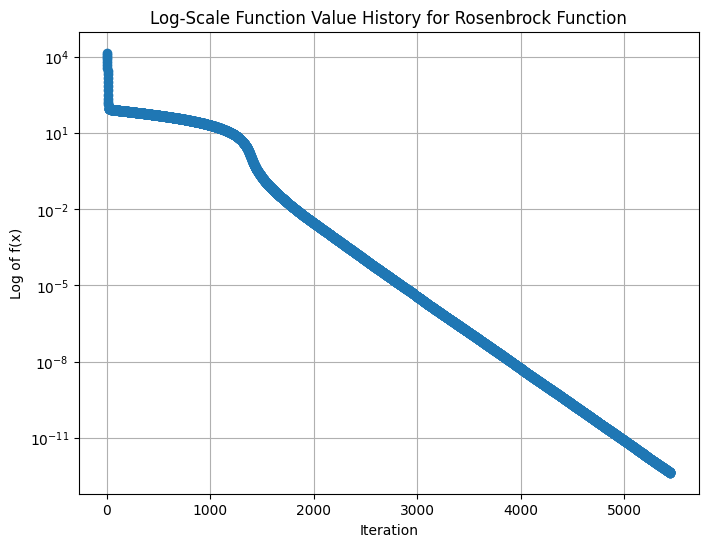

In [34]:
# @title Rand Descent Exp (u ~ uniform [-1, 1] and Normalized, g normalized)

iter_list = []
time_list = []
for i in range(0, num_trials):
    # Run gradient descent
    solution_rosenbrock_rand, f_hist_rosenbrock_rand, x_hist_rosenbrock_rand, iterations_rosenbrock_rand, time_rosenbrock_rand = random_descent(
        rosenbrock_100d, grad_rosenbrock_function, x0, rand_scale= 1, randtype = "uniform", randnormed = True, gradnormed = True)

    iter_list.append(iterations_rosenbrock_rand)
    time_list.append(time_rosenbrock_rand)
print("average iteration count (in ", num_trials, " trials) = ", sum(iter_list) / len(iter_list))
print("average time (in ", num_trials, " trials) = ", sum(time_list) / len(time_list))

# Plotting the function value history on a log-scale
plt.figure(figsize=(8, 6))
plt.plot(f_hist_rosenbrock_rand, marker='o', linestyle='-')
plt.yscale('log')
plt.title('Log-Scale Function Value History for Rosenbrock Function')
plt.xlabel('Iteration')
plt.ylabel('Log of f(x)')
plt.grid(True)
plt.show()

In [35]:
# @title Rand Descent Exp (u ~ normal and Normalized, g normalized)

iter_list = []
time_list = []
for i in range(0, num_trials):
    # Run gradient descent
    solution_rosenbrock_rand, f_hist_rosenbrock_rand, x_hist_rosenbrock_rand, iterations_rosenbrock_rand, time_rosenbrock_rand = random_descent(
        rosenbrock_100d, grad_rosenbrock_function, x0, rand_scale= 1, randtype = "normal", randnormed = True, gradnormed = True)

    iter_list.append(iterations_rosenbrock_rand)
    time_list.append(time_rosenbrock_rand)
print("average iteration count (in ", num_trials, " trials) = ", sum(iter_list) / len(iter_list))
print("average time (in ", num_trials, " trials) = ", sum(time_list) / len(time_list))

Converged!!
average iteration count (in  1  trials) =  5407.0
average time (in  1  trials) =  345.6146402359009


Converged!!
average iteration count (in  1  trials) =  3474.0
average time (in  1  trials) =  198.05928111076355


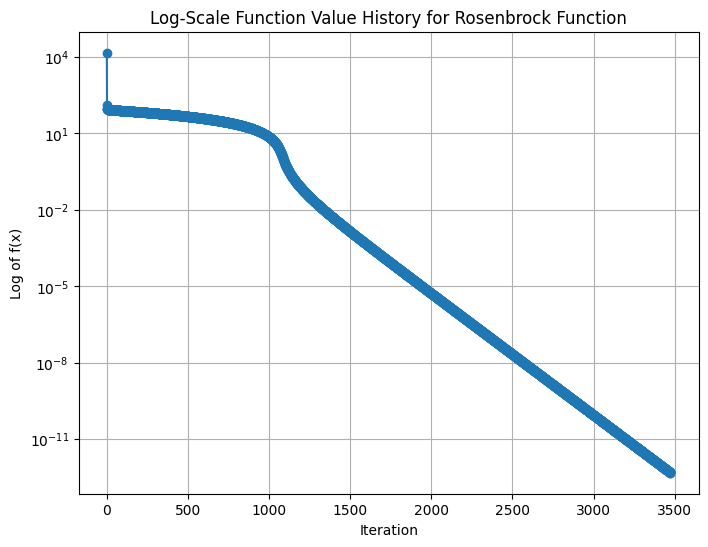

In [36]:
# @title grad descent

iter_list = []
time_list = []
for i in range(0, num_trials):
    # Run gradient descent
    solution_rosenbrock_rand, f_hist_rosenbrock_rand, x_hist_rosenbrock_rand, iterations_rosenbrock_rand, time_rosenbrock_rand = gradient_descent(
        rosenbrock_100d, grad_rosenbrock_function, x0)

    iter_list.append(iterations_rosenbrock_rand)
    time_list.append(time_rosenbrock_rand)
print("average iteration count (in ", num_trials, " trials) = ", sum(iter_list) / len(iter_list))
print("average time (in ", num_trials, " trials) = ", sum(time_list) / len(time_list))

# Plotting the function value history on a log-scale
plt.figure(figsize=(8, 6))
plt.plot(f_hist_rosenbrock_rand, marker='o', linestyle='-')
plt.yscale('log')
plt.title('Log-Scale Function Value History for Rosenbrock Function')
plt.xlabel('Iteration')
plt.ylabel('Log of f(x)')
plt.grid(True)
plt.show()
